<a href="https://colab.research.google.com/github/vvrgit/ML-Optimization/blob/main/ADAM_UDEMY_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

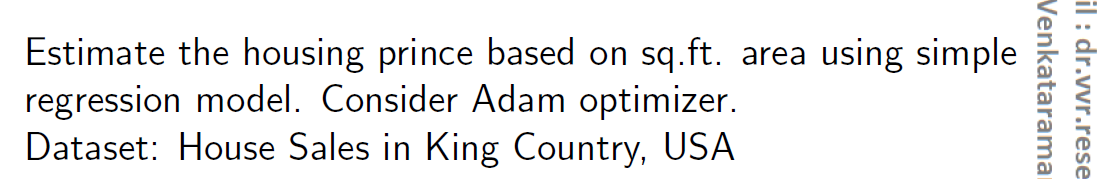

In [1]:
import pandas as pd
import numpy as np
import math as mt
import random

In [3]:
data=pd.read_csv("/content/Housing.csv")
data.head()

,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


In [4]:
area_min=data["area"].min()
area_max=data["area"].max()
price_min=data["price"].min()
price_max=data["price"].max()

In [5]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
ms.fit(data)
data_norm=ms.fit_transform(data)
data_norm

array([[1.        , 0.39656357],
       [0.90909091, 0.5024055 ],
       [0.90909091, 0.57113402],
       ...,
       [0.        , 0.13539519],
       [0.        , 0.08659794],
       [0.        , 0.15120275]])

In [6]:
data=pd.DataFrame(data_norm,columns=data.columns)
data.head()

,price,area
0,1.000000,0.396564
1,0.909091,0.502405
2,0.909091,0.571134
3,0.906061,0.402062
4,0.836364,0.396564


In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data["area"],data["price"],test_size=0.2)
x_train=np.array(x_train)
y_train=np.array(y_train)
x_test=np.array(x_test)
y_test=np.array(y_test)

In [32]:
eta=0.1
epochs=5000
beta1=0.9
beta2=0.999
eps=mt.pow(10,-8)

m1=random.uniform(-1,1)
m2=random.uniform(-1,1)
c=random.uniform(-1,1)

Em11=0
Em21=0
Ec1=0

Em12=0
Em22=0
Ec2=0

t=0

Ns=x_train.shape[0]

In [33]:
for iter in range(epochs):
  t=t+1
  #Gradient Caluclation
  gm1=0
  gm2=0
  gc=0
  for sample in range(Ns):
    x=x_train[sample]
    y=y_train[sample]
    gm1=gm1+(y-m1*x*x-m2*x-c)*x*x
    gm2=gm2+(y-m1*x*x-m2*x-c)*x
    gc=gc+(y-m1*x*x-m2*x-c)
  gm1=(-1/Ns)*gm1
  gm2=(-1/Ns)*gm2
  gc=(-1/Ns)*gc

  #First moment Estimation
  Em11=beta1*Em11+(1-beta1)*gm1
  Em21=beta1*Em21+(1-beta1)*gm2
  Ec1=beta1*Ec1+(1-beta1)*gc

  #second moment estimation
  Em12=beta2*Em12+(1-beta2)*gm1*gm1
  Em22=beta2*Em22+(1-beta2)*gm2*gm2
  Ec2=beta2*Ec2+(1-beta2)*gc*gc

  #Correction in First moment
  Em11=Em11/(1-mt.pow(beta1,t))
  Em21=Em21/(1-mt.pow(beta1,t))
  Ec1=Ec1/(1-mt.pow(beta1,t))

  #Correction in Second moment
  Em12=Em12/(1-mt.pow(beta2,t))
  Em22=Em22/(1-mt.pow(beta2,t))
  Ec2=Ec2/(1-mt.pow(beta2,t))

  #Update
  m1=m1-(eta*Em11)/(mt.sqrt(Em12)+eps)
  m2=m2-(eta*Em21)/(mt.sqrt(Em22)+eps)
  c=c-(eta*Ec1)/(mt.sqrt(Ec2)+eps)
print(m1,m2,c)

/tmp/ipykernel_21903/521535623.py:35: RuntimeWarning: overflow encountered in scalar divide
  Ec2=Ec2/(1-mt.pow(beta2,t))
/tmp/ipykernel_21903/521535623.py:34: RuntimeWarning: overflow encountered in scalar divide
  Em22=Em22/(1-mt.pow(beta2,t))
/tmp/ipykernel_21903/521535623.py:33: RuntimeWarning: overflow encountered in scalar divide
  Em12=Em12/(1-mt.pow(beta2,t))


0.6515215813652845 -0.6812108283749536 0.7920844685218754


# **Preiction with training data**

In [34]:
y_pred_train=np.zeros(x_train.shape[0])
for sample in range(x_train.shape[0]):
  y_pred_train[sample]=m1*x_train[sample]*x_train[sample]+m2*x_train[sample]+c

# **Preiction with test data**

In [35]:
y_pred_test=np.zeros(x_test.shape[0])
for sample in range(x_test.shape[0]):
  y_pred_test[sample]=m1*x_test[sample]*x_test[sample]+m2*x_test[sample]+c
y_pred_test

array([0.66873669, 0.74997485, 0.65338737, 0.72833041, 0.76966333,
       0.6400197 , 0.66466301, 0.77607495, 0.64665813, 0.64546657,
       0.66925698, 0.6325925 , 0.70972489, 0.70565035, 0.73448815,
       0.6890182 , 0.6357396 , 0.68660713, 0.61422372, 0.69938026,
       0.64665813, 0.71110277, 0.71600289, 0.65019676, 0.65979249,
       0.73218867, 0.74163841, 0.64910774, 0.61903603, 0.69905641,
       0.62664745, 0.66219697, 0.68660713, 0.67943989, 0.61422372,
       0.67405038, 0.64046887, 0.68630852, 0.63166689, 0.64665813,
       0.63656485, 0.6807518 , 0.6446845 , 0.61813751, 0.73448815,
       0.61442783, 0.64665813, 0.75743832, 0.63476962, 0.61888013,
       0.69905641, 0.74283025, 0.69585176, 0.64665813, 0.66219697,
       0.61404644, 0.71600289, 0.65756523, 0.70903965, 0.6325925 ,
       0.62082173, 0.76830936, 0.73564619, 0.66188017, 0.6387825 ,
       0.69521822, 0.71885713, 0.69776716, 0.67596834, 0.68306438,
       0.70699868, 0.66171115, 0.72357928, 0.72765619, 0.76966

**Calculate Training Errors**

In [36]:
from sklearn.metrics import mean_squared_error
mse_train=mean_squared_error(y_train,y_pred_train)
mse_test=mean_squared_error(y_test,y_pred_test)
print(mse_train,mse_test)

0.21394162982188478 0.20182910452068564


# **Deploy model**

In [37]:
area=input("enter area value")
area=float(area)
area=(area*area_min)/(area_max-area_min)
price=m1*(area*area)+m2*area+c
price=price*(price_max-price_min)+price_min
print(price)

enter area value7000
4735625664793.566
